In [ ]:
!pip install yt-dlp pydub noisereduce soundfile librosa pysrt -q
!pip install silero-vad -q
!apt-get install -y ffmpeg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

VIDEO_PATH = "/content/drive/MyDrive/miniprojectfinal/"
print(os.listdir(VIDEO_PATH))

Mounted at /content/drive
['Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].mkv', 'news-debate.mp4', 'podcast.mp4']


In [ ]:
import subprocess

result = subprocess.run(
    ["ffprobe", "-v", "error", "-show_streams", "-select_streams", "a",
     "-of", "default=noprint_wrappers=1", "/content/drive/MyDrive/miniprojectfinal/Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].mkv"],
    capture_output=True, text=True
)
print(result.stdout)

index=1
codec_name=aac
codec_long_name=AAC (Advanced Audio Coding)
profile=HE-AAC
codec_type=audio
codec_tag_string=[0][0][0][0]
codec_tag=0x0000
sample_fmt=fltp
sample_rate=48000
channels=2
channel_layout=stereo
bits_per_sample=0
id=N/A
r_frame_rate=0/0
avg_frame_rate=0/0
time_base=1/1000
start_pts=0
start_time=0.000000
duration_ts=N/A
duration=N/A
bit_rate=N/A
max_bit_rate=N/A
bits_per_raw_sample=N/A
nb_frames=N/A
nb_read_frames=N/A
nb_read_packets=N/A
DISPOSITION:default=1
DISPOSITION:dub=0
DISPOSITION:original=0
DISPOSITION:comment=0
DISPOSITION:lyrics=0
DISPOSITION:karaoke=0
DISPOSITION:forced=0
DISPOSITION:hearing_impaired=0
DISPOSITION:visual_impaired=0
DISPOSITION:clean_effects=0
DISPOSITION:attached_pic=0
DISPOSITION:timed_thumbnails=0
TAG:language=hin
TAG:title=
TAG:DURATION=01:49:12.107000000
index=2
codec_name=aac
codec_long_name=AAC (Advanced Audio Coding)
profile=HE-AAC
codec_type=audio
codec_tag_string=[0][0][0][0]
codec_tag=0x0000
sample_fmt=fltp
sample_rate=48000
chann

In [ ]:
import subprocess
import os

AUDIO_PATH = "/content/drive/MyDrive/miniprojectfinal/audio_files"
os.makedirs(AUDIO_PATH, exist_ok=True)

# Specify which audio stream to extract per video (0-indexed)
# For dual-audio video, set the stream index of the Assamese track
# For single-audio videos, stream 0 is fine
AUDIO_STREAM_MAP = {
    "Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].mkv": 1,  # ← Change this to your actual filename
                                 #   and the correct stream index (0 or 1)
}

video_files = [f for f in os.listdir(VIDEO_PATH)
               if f.endswith(('.mp4', '.mkv', '.avi'))]

for video in video_files:
    input_path  = os.path.join(VIDEO_PATH, video)
    output_name = os.path.splitext(video)[0] + ".wav"
    output_path = os.path.join(AUDIO_PATH, output_name)

    if os.path.exists(output_path):
        print(f"Already exists, skipping: {output_name}")
        continue

    # Pick stream index: use mapping if defined, else default to 0
    stream_index = AUDIO_STREAM_MAP.get(video, 0)

    cmd = [
        "ffmpeg", "-i", input_path,
        "-map", f"0:a:{stream_index}",  # ← picks specific audio stream
        "-ac", "1",       # mono
        "-ar", "16000",   # 16kHz
        "-vn",            # no video
        output_path, "-y"
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print(f"Extracted (stream a:{stream_index}): {output_name}")

print("\nAll audio files:")
print(os.listdir(AUDIO_PATH))

Extracted (stream a:1): Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].wav
Extracted (stream a:0): news-debate.wav
Extracted (stream a:0): podcast.wav

All audio files:
['Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].wav', 'news-debate.wav', 'podcast.wav']


In [ ]:
import librosa
import numpy as np

audio_files = [f for f in os.listdir(AUDIO_PATH) if f.endswith('.wav')]

print(f"Total audio files: {len(audio_files)}\n")

for fname in audio_files:
    fpath = os.path.join(AUDIO_PATH, fname)
    y, sr = librosa.load(fpath, sr=16000)
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"{fname}")
    print(f"  Duration : {duration/60:.1f} minutes")
    print(f"  SR       : {sr} Hz")
    print(f"  Samples  : {len(y)}")

Total audio files: 3

Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].wav
  Duration : 109.2 minutes
  SR       : 16000 Hz
  Samples  : 104833707
news-debate.wav
  Duration : 72.1 minutes
  SR       : 16000 Hz
  Samples  : 69221100
podcast.wav
  Duration : 63.8 minutes
  SR       : 16000 Hz
  Samples  : 61294736


In [ ]:
import torch
import torchaudio
import soundfile as sf
import os



# Load silero VAD model
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False
)

(get_speech_timestamps,
 save_audio,
 read_audio,
 VADIterator,
 collect_chunks) = vad_utils

def segment_audio_vad(audio_path, output_dir, filename_prefix,
                       min_dur=1.5, max_dur=8.0):
    """
    Segments a long audio file into utterances using VAD.
    Keeps segments between min_dur and max_dur seconds.
    """
    wav = read_audio(audio_path, sampling_rate=16000)

    speech_timestamps = get_speech_timestamps(
        wav, vad_model,
        sampling_rate=16000,
        threshold=0.5,           # confidence threshold
        min_speech_duration_ms=500,
        min_silence_duration_ms=300,
        speech_pad_ms=100        # add 100ms padding around speech
    )

    print(f"Found {len(speech_timestamps)} speech segments")

    saved, skipped = 0, 0
    segment_info = []

    for i, ts in enumerate(speech_timestamps):
        start  = ts['start']
        end    = ts['end']
        duration = (end - start) / 16000

        if not (min_dur <= duration <= max_dur):
            skipped += 1
            continue

        segment = wav[start:end]
        fname   = f"{filename_prefix}_seg{i:04d}.wav"
        fpath   = os.path.join(output_dir, fname)
        save_audio(fpath, segment, sampling_rate=16000)

        segment_info.append({
            'filename' : fpath,
            'duration' : round(duration, 2),
            'start_sample': start,
            'end_sample'  : end,
        })
        saved += 1

    print(f"Saved: {saved} | Skipped (wrong duration): {skipped}")
    return segment_info

SEGMENT_PATH = "/content/drive/MyDrive/miniprojectfinal/segmented_audio"
os.makedirs(SEGMENT_PATH, exist_ok=True)
# Run VAD on all audio files
all_segments = []

for fname in audio_files:
    fpath  = os.path.join(AUDIO_PATH, fname)
    prefix = os.path.splitext(fname)[0][:20]  # short prefix
    print(f"\nProcessing: {fname}")
    segs = segment_audio_vad(fpath, SEGMENT_PATH, prefix)
    all_segments.extend(segs)

print(f"\nTotal segments extracted: {len(all_segments)}")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip

Processing: Aamis (2019) Dual Audio {Hindi-Assamese} 480p WEB-DL ESub [BollyFlix].wav
Found 944 speech segments


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:178: UserWarning: The 'bits_per_sample' parameter is not directly supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(


Saved: 446 | Skipped (wrong duration): 498

Processing: news-debate.wav
Found 368 speech segments
Saved: 213 | Skipped (wrong duration): 155

Processing: podcast.wav
Found 127 speech segments
Saved: 38 | Skipped (wrong duration): 89

Total segments extracted: 697


In [ ]:
import noisereduce as nr
from pathlib import Path
import librosa # Added import
import numpy as np # Added import
import soundfile as sf # Added import
import os # Added import

def preprocess_segment(input_path, output_path):
    """
    Full preprocessing pipeline:
    noise reduction → silence trim → RMS normalize
    Returns True if segment is valid, False if too short after trimming.
    """
    try:
        y, sr = librosa.load(input_path, sr=16000)

        # 1. Noise reduction
        noise_sample = y[:sr//4]  # first 0.25s as noise reference
        y = nr.reduce_noise(y=y, sr=sr, y_noise=noise_sample,
                            prop_decrease=0.8)

        # 2. Silence trimming
        y, _ = librosa.effects.trim(y, top_db=25)

        # 3. Check minimum duration after trimming
        if len(y) < sr * 1.0:  # less than 1 second → discard
            return False

        # 4. RMS normalization
        rms = np.sqrt(np.mean(y ** 2))
        if rms > 0:
            y = y * (0.1 / rms)

        # 5. Clip to prevent any extreme values
        y = np.clip(y, -1.0, 1.0)

        sf.write(output_path, y, sr)
        return True

    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return False

# Define BASE_PATH using MOVIE_PATH from previous cells
BASE_PATH = VIDEO_PATH.rstrip('/') # Ensures no trailing slash

# Create preprocessed output folder
PREPROCESSED_PATH = f"{BASE_PATH}/data/preprocessed"
os.makedirs(PREPROCESSED_PATH, exist_ok=True)

segment_files = [f for f in os.listdir(SEGMENT_PATH) if f.endswith('.wav')]
print(f"Total segments to preprocess: {len(segment_files)}")

valid, invalid = 0, 0
valid_files = []

for fname in segment_files:
    input_path  = os.path.join(SEGMENT_PATH, fname)
    output_path = os.path.join(PREPROCESSED_PATH, fname)

    if preprocess_segment(input_path, output_path):
        valid_files.append(output_path)
        valid += 1
    else:
        invalid += 1

print(f"\nValid segments   : {valid}")
print(f"Discarded        : {invalid}")
print(f"Ready for labeling: {valid}")

Total segments to preprocess: 697

Valid segments   : 697
Discarded        : 0
Ready for labeling: 697


In [ ]:
def extract_pitch_energy(filepath):
    """Extract pitch and energy features for auto-labeling."""
    y, sr = librosa.load(filepath, sr=16000)

    # Pitch (F0) using PYIN
    f0, voiced_flag, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz('C2'),  # 65 Hz
        fmax=librosa.note_to_hz('C7'),  # 2093 Hz
        sr=sr
    )
    f0_voiced = f0[voiced_flag]  # only voiced frames

    pitch_mean  = np.nanmean(f0_voiced) if len(f0_voiced) > 0 else 0
    pitch_std   = np.nanstd(f0_voiced)  if len(f0_voiced) > 0 else 0
    pitch_range = (np.nanmax(f0_voiced) - np.nanmin(f0_voiced)) if len(f0_voiced) > 0 else 0

    # RMS Energy
    rms      = librosa.feature.rms(y=y)[0]
    rms_mean = np.mean(rms)
    rms_std  = np.std(rms)
    rms_max  = np.max(rms)

    # ZCR
    zcr      = librosa.feature.zero_crossing_rate(y)[0]
    zcr_mean = np.mean(zcr)

    return {
        'pitch_mean'  : pitch_mean,
        'pitch_std'   : pitch_std,
        'pitch_range' : pitch_range,
        'rms_mean'    : rms_mean,
        'rms_std'     : rms_std,
        'rms_max'     : rms_max,
        'zcr_mean'    : zcr_mean,
    }


def auto_label_stress(features, pitch_threshold, energy_threshold):
    """
    Rule-based labeling:
    Stressed (1) if pitch OR energy is above threshold.
    """
    high_pitch  = features['pitch_mean']  > pitch_threshold
    high_energy = features['rms_mean']    > energy_threshold
    high_range  = features['pitch_range'] > pitch_threshold * 0.5

    # Stressed if at least 2 of 3 conditions are true
    score = sum([high_pitch, high_energy, high_range])
    return 1 if score >= 2 else 0


# First pass — extract features from all valid files
print("Extracting pitch and energy features...")
feature_list = []

for fpath in valid_files:
    feats = extract_pitch_energy(fpath)
    feats['filename'] = fpath
    feature_list.append(feats)

import pandas as pd
feat_df = pd.DataFrame(feature_list)

# Compute thresholds from the data itself (mean values)
pitch_threshold  = feat_df['pitch_mean'].median()
energy_threshold = feat_df['rms_mean'].median()

print(f"Pitch threshold  : {pitch_threshold:.2f} Hz")
print(f"Energy threshold : {energy_threshold:.4f}")

# Apply auto-labeling
feat_df['label'] = feat_df.apply(
    lambda row: auto_label_stress(row, pitch_threshold, energy_threshold),
    axis=1
)
feat_df['language'] = 'assamese'  # change to 'bodo' if applicable
# feat_df['source']   = 'news'

print(f"\nLabel distribution:")
print(feat_df['label'].value_counts())

Extracting pitch and energy features...
Pitch threshold  : 184.63 Hz
Energy threshold : 0.0865

Label distribution:
label
1    396
0    301
Name: count, dtype: int64


In [ ]:
# Select only needed columns for final CSV
movie_df = feat_df[['filename', 'label', 'language']].copy()

# Define CSV_PATH
CSV_PATH = f"{BASE_PATH}/data/labeled_segments.csv"

movie_df.to_csv(CSV_PATH, index=False)
print(f"Saved {len(movie_df)} labeled segments to:")
print(CSV_PATH)
print(movie_df.head())

Saved 697 labeled segments to:
/content/drive/MyDrive/miniprojectfinal/data/labeled_segments.csv
                                            filename  label  language
0  /content/drive/MyDrive/miniprojectfinal/data/p...      1  assamese
1  /content/drive/MyDrive/miniprojectfinal/data/p...      1  assamese
2  /content/drive/MyDrive/miniprojectfinal/data/p...      1  assamese
3  /content/drive/MyDrive/miniprojectfinal/data/p...      1  assamese
4  /content/drive/MyDrive/miniprojectfinal/data/p...      1  assamese


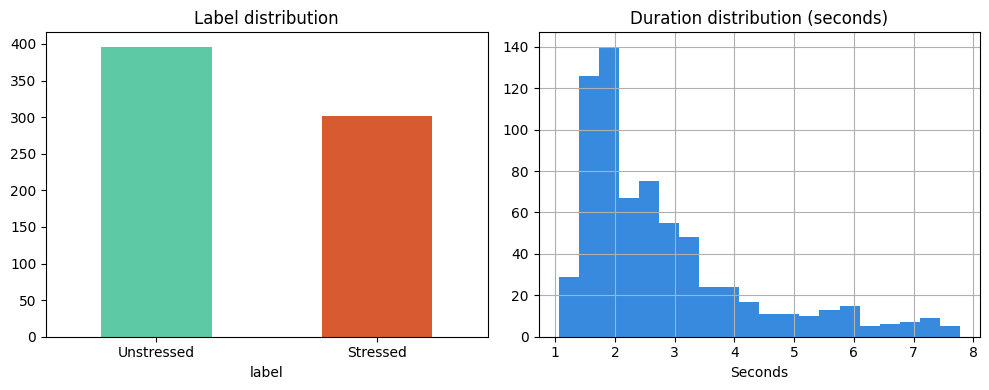


Final dataset stats:
Total samples  : 697
Mean duration  : 2.79s
language  label
assamese  0        301
          1        396
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import os

# Adjust subplot creation for 1 row, 2 columns (removing the 'source' plot)
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # Changed from (1,3) to (1,2) and figsize adjusted

# Label distribution
movie_df['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#5DCAA5','#D85A30'],
    title='Label distribution')
axes[0].set_xticklabels(['Unstressed', 'Stressed'], rotation=0)

# Duration distribution
durations = []
for fpath in movie_df['filename']:
    try:
        y, sr = librosa.load(fpath, sr=16000)
        durations.append(librosa.get_duration(y=y, sr=sr))
    except:
        durations.append(0)

movie_df['duration'] = durations
# The duration plot is now at axes[1] instead of axes[2]
movie_df['duration'].hist(ax=axes[1], bins=20, color='#378ADD')
axes[1].set_title('Duration distribution (seconds)')
axes[1].set_xlabel('Seconds')

plt.tight_layout()

# Ensure the results directory exists before saving
results_path = f"{BASE_PATH}/results"
os.makedirs(results_path, exist_ok=True)

plt.savefig(f"{results_path}/dataset_summary.png", dpi=150)
plt.show()

print(f"\nFinal dataset stats:")
print(f"Total samples  : {len(movie_df)}")
print(f"Mean duration  : {movie_df['duration'].mean():.2f}s")
print(movie_df.groupby(['language','label']).size())

In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Processor

MODEL_NAME = "facebook/wav2vec2-base"
DEVICE     = "cuda"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model     = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels        = 2,           # adjust to your number of stress classes
    problem_type      = "single_label_classification",
    ignore_mismatched_sizes = True
).to(DEVICE)

model.freeze_feature_encoder()       # freeze CNN, only fine-tune transformer layers

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch
from torch.utils.data import Dataset
import librosa
import numpy as np
import pandas as pd

class StressDataset(Dataset):
    def __init__(self, dataframe, processor, max_length=16000*6):
        self.df         = dataframe.reset_index(drop=True)
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, sr = librosa.load(row['filename'], sr=16000)

        # Pad or truncate to max_length
        if len(y) > self.max_length:
            y = y[:self.max_length]
        else:
            y = np.pad(y, (0, self.max_length - len(y)))

        inputs = self.processor(
            y,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values" : inputs.input_values.squeeze(),
            "labels"       : torch.tensor(row['label'], dtype=torch.long)
        }

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(CSV_PATH) # Changed path to use the correct variable
df['stratify_key'] = df['language'] + "_" + df['label'].astype(str)

train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df['stratify_key'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['stratify_key'],
    random_state=42
)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")
print(f"\nTrain label dist:\n{train_df['label'].value_counts()}")

train_dataset = StressDataset(train_df, processor)
val_dataset   = StressDataset(val_df,   processor)
test_dataset  = StressDataset(test_df,  processor)

Train : 487
Val   : 105
Test  : 105

Train label dist:
label
1    277
0    210
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    return {
        "accuracy"    : round(acc, 4),
        "f1_macro"    : round(f1, 4),
        "f1_class_0"  : round(f1_per_class[0], 4),
        "f1_class_1"  : round(f1_per_class[1], 4),
    }

In [ ]:
from transformers import TrainingArguments, Trainer

total_steps = (len(train_dataset) / 8) * 50  # total training steps

training_args = TrainingArguments(
    output_dir                  = "/content/stress_model",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    logging_strategy            = "epoch",
    num_train_epochs            = 50,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate               = 3e-5,          # ← lowered: wav2vec2-base is pretrained, needs gentler LR
    warmup_steps                = int(0.1 * total_steps),  # ← fixed: was computing wrong (15 was hardcoded)
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    fp16                        = True,
    report_to                   = "none",
    save_total_limit            = 2,
    dataloader_num_workers      = 2,             # ← speeds up data loading in Colab
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("Starting training...")
trainer.train()

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Class 0,F1 Class 1
1,0.691119,0.679887,0.571400,0.363600,0.000000,0.727300
2,0.644796,0.548665,0.742900,0.736700,0.696600,0.776900
3,0.501052,0.626696,0.685700,0.685700,0.685700,0.685700
4,0.455265,0.438868,0.809500,0.799900,0.756100,0.843800
5,0.396159,0.535868,0.761900,0.761800,0.766400,0.757300
6,0.364956,0.434926,0.838100,0.835200,0.813200,0.857100
7,0.393657,0.554258,0.771400,0.755200,0.692300,0.818200
8,0.321704,0.543514,0.838100,0.834200,0.809000,0.859500
9,0.257036,0.774386,0.761900,0.743700,0.675300,0.812000
10,0.195595,0.555852,0.847600,0.845900,0.829800,0.862100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3050, training_loss=0.11479156097916306, metrics={'train_runtime': 1965.4848, 'train_samples_per_second': 12.389, 'train_steps_per_second': 1.552, 'total_flos': 1.326388228704e+18, 'train_loss': 0.11479156097916306, 'epoch': 50.0})

In [ ]:
print("Evaluating on test set...")
results = trainer.evaluate(test_dataset)

print(f"\nTest Results:")
print(f"  Accuracy  : {results['eval_accuracy']}")
print(f"  F1 Macro  : {results['eval_f1_macro']}")
print(f"  F1 Class 0: {results['eval_f1_class_0']}")
print(f"  F1 Class 1: {results['eval_f1_class_1']}")

Evaluating on test set...



Test Results:
  Accuracy  : 0.7905
  F1 Macro  : 0.7882
  F1 Class 0: 0.766
  F1 Class 1: 0.8103


In [ ]:
save_path = "/content/drive/MyDrive/miniprojectfinal"

model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/miniprojectfinal


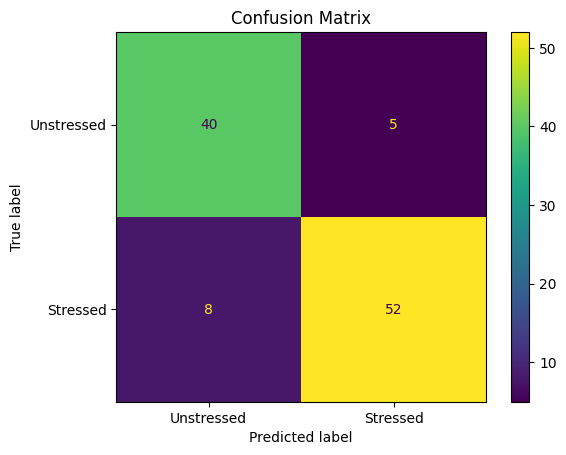

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(val_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Unstressed", "Stressed"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("/content/confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["Unstressed", "Stressed"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
print(report_df)

report_df.to_csv("/content/classification_report.csv")

              precision    recall  f1-score    support
Unstressed     0.833333  0.888889  0.860215   45.00000
Stressed       0.912281  0.866667  0.888889   60.00000
accuracy       0.876190  0.876190  0.876190    0.87619
macro avg      0.872807  0.877778  0.874552  105.00000
weighted avg   0.878446  0.876190  0.876600  105.00000


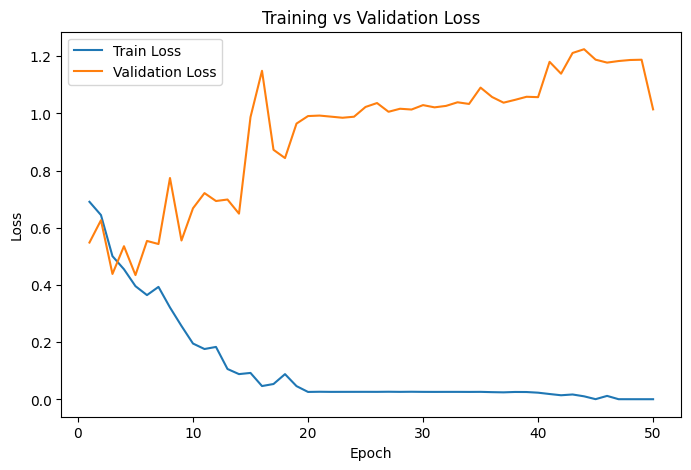

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = []
eval_loss = []
epochs = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs.append(log["epoch"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

# Ensure eval_loss has the same length as epochs for plotting
# Assuming the extra eval_loss entry is an initial evaluation (epoch 0 equivalent)
# or an extra evaluation that should be excluded to match the train epochs.
if len(eval_loss) > len(epochs):
    # Slice eval_loss to match the length of epochs
    eval_loss_to_plot = eval_loss[len(eval_loss) - len(epochs):]
else:
    eval_loss_to_plot = eval_loss

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Train Loss") # Use epochs directly for train_loss
plt.plot(epochs, eval_loss_to_plot, label="Validation Loss") # Use the adjusted eval_loss

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("/content/loss_curve.png", dpi=300)
plt.show()

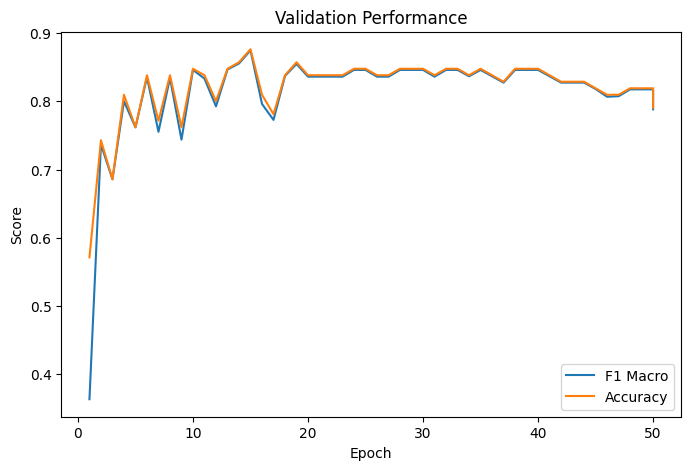

In [ ]:
eval_f1 = []
eval_accuracy = []
eval_epochs = []

for log in log_history:
    if "eval_f1_macro" in log:
        eval_f1.append(log["eval_f1_macro"])
        eval_epochs.append(log["epoch"])

    if "eval_accuracy" in log:
        eval_accuracy.append(log["eval_accuracy"])

plt.figure(figsize=(8,5))
plt.plot(eval_epochs[:len(eval_f1)], eval_f1, label="F1 Macro")
plt.plot(eval_epochs[:len(eval_accuracy)], eval_accuracy, label="Accuracy")

plt.title("Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.savefig("/content/performance_curve.png", dpi=300)
plt.show()

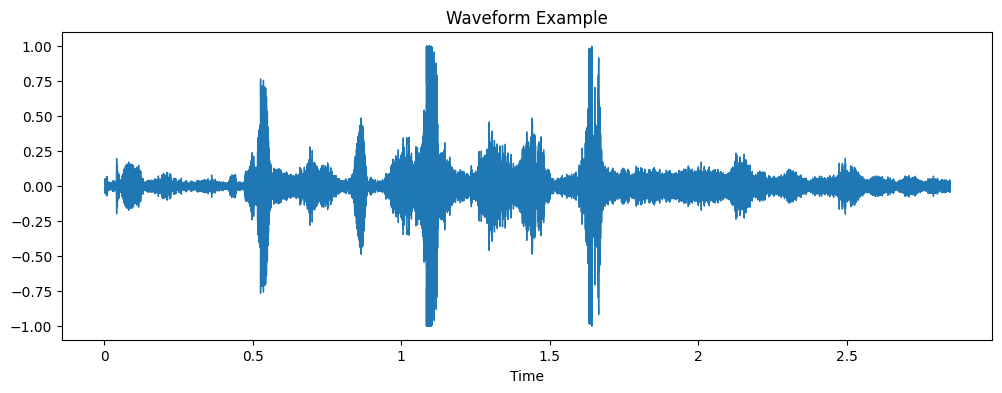

In [ ]:
import librosa.display

sample_file = df['filename'].iloc[0]

y, sr = librosa.load(sample_file, sr=16000)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)

plt.title("Waveform Example")
plt.savefig("/content/waveform.png", dpi=300)
plt.show()

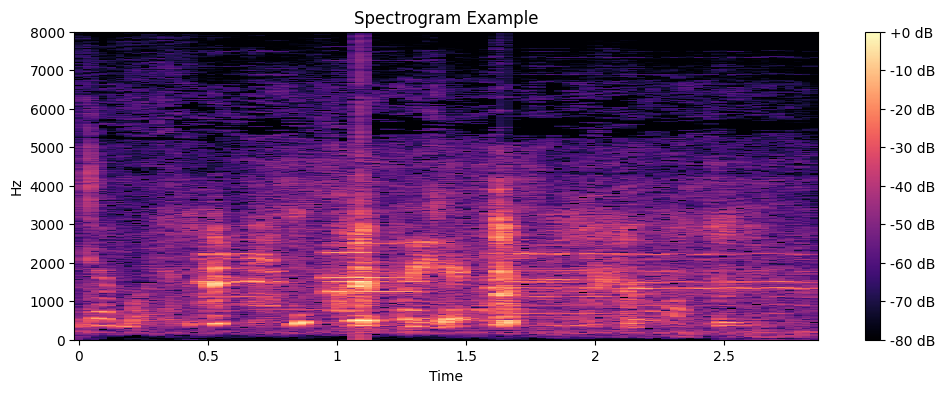

In [ ]:
D = librosa.amplitude_to_db(
    abs(librosa.stft(y)),
    ref=np.max
)

plt.figure(figsize=(12,4))
librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram Example")
plt.savefig("/content/spectrogram.png", dpi=300)
plt.show()

In [ ]:
import torch
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from torch.utils.data import DataLoader

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "facebook/wav2vec2-base"

# Load base model (no classification head) for embedding extraction
embed_processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
embed_model     = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(DEVICE)
embed_model.eval()

def extract_embeddings(dataset, batch_size=16):
    all_embeddings = []
    all_labels     = []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            input_values = batch["input_values"].to(DEVICE)
            labels       = batch["labels"]

            outputs      = embed_model(input_values)
            # Mean-pool over time dimension → (batch, 768)
            embeddings   = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

            all_embeddings.append(embeddings)
            all_labels.append(labels.numpy())

    return np.vstack(all_embeddings), np.concatenate(all_labels)

print("Extracting train embeddings...")
X_train, y_train = extract_embeddings(train_dataset)

print("Extracting val embeddings...")
X_val, y_val     = extract_embeddings(val_dataset)

print("Extracting test embeddings...")
X_test, y_test   = extract_embeddings(test_dataset)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting train embeddings...
Extracting val embeddings...
Extracting test embeddings...
Train: (487, 768), Val: (105, 768), Test: (105, 768)


In [ ]:
# Classical ML uses CV internally, so combine train and val
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f"Combined train+val: {X_trainval.shape}")

Combined train+val: (592, 768)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
X_trainval = scaler.fit_transform(X_trainval)
X_test     = scaler.transform(X_test)   # use same scaler, never fit on test

print("Features scaled.")

Features scaled.


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "SVM"                 : SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost"             : XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          use_label_encoder=False, eval_metric="logloss",
                                          random_state=42, n_jobs=-1),
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

results = {}

for name, clf in models.items():
    print(f"\nTraining {name}...")
    clf.fit(X_trainval, y_trainval)

    preds = clf.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    f1m   = f1_score(y_test, preds, average="macro")
    f1_0  = f1_score(y_test, preds, pos_label=0, average="binary")
    f1_1  = f1_score(y_test, preds, pos_label=1, average="binary")

    results[name] = {"Accuracy": acc, "F1 Macro": f1m, "F1 Class 0": f1_0, "F1 Class 1": f1_1}

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Macro  : {f1m:.4f}")
    print(f"  F1 Class 0: {f1_0:.4f}")
    print(f"  F1 Class 1: {f1_1:.4f}")


Training SVM...
  Accuracy  : 0.7048
  F1 Macro  : 0.6958
  F1 Class 0: 0.6437
  F1 Class 1: 0.7480

Training Random Forest...
  Accuracy  : 0.7143
  F1 Macro  : 0.6971
  F1 Class 0: 0.6250
  F1 Class 1: 0.7692

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:26:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy  : 0.7048
  F1 Macro  : 0.6977
  F1 Class 0: 0.6517
  F1 Class 1: 0.7438

Training Logistic Regression...
  Accuracy  : 0.7619
  F1 Macro  : 0.7588
  F1 Class 0: 0.7312
  F1 Class 1: 0.7863

Training KNN...
  Accuracy  : 0.6571
  F1 Macro  : 0.6399
  F1 Class 0: 0.5610
  F1 Class 1: 0.7188


In [ ]:
import pandas as pd

# Add your wav2vec2 fine-tuned results as baseline
results["wav2vec2-base (fine-tuned)"] = {
    "Accuracy" : 0.7905,
    "F1 Macro" : 0.7882,
    "F1 Class 0": 0.7660,
    "F1 Class 1": 0.8103,
}

df = pd.DataFrame(results).T.sort_values("F1 Macro", ascending=False)
df = df.round(4)

print("\n===== FINAL COMPARISON =====")
print(df.to_string())


===== FINAL COMPARISON =====
                            Accuracy  F1 Macro  F1 Class 0  F1 Class 1
wav2vec2-base (fine-tuned)    0.7905    0.7882      0.7660      0.8103
Logistic Regression           0.7619    0.7588      0.7312      0.7863
XGBoost                       0.7048    0.6977      0.6517      0.7438
Random Forest                 0.7143    0.6971      0.6250      0.7692
SVM                           0.7048    0.6958      0.6437      0.7480
KNN                           0.6571    0.6399      0.5610      0.7188


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.dpi"      : 150,
    "font.family"     : "DejaVu Sans",
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

VISUAL_PATH = "/content/drive/MyDrive/miniprojectfinal/visuals"
os.makedirs(VISUAL_PATH, exist_ok=True)

def save(filename):
    path = os.path.join(VISUAL_PATH, filename)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved → {path}")

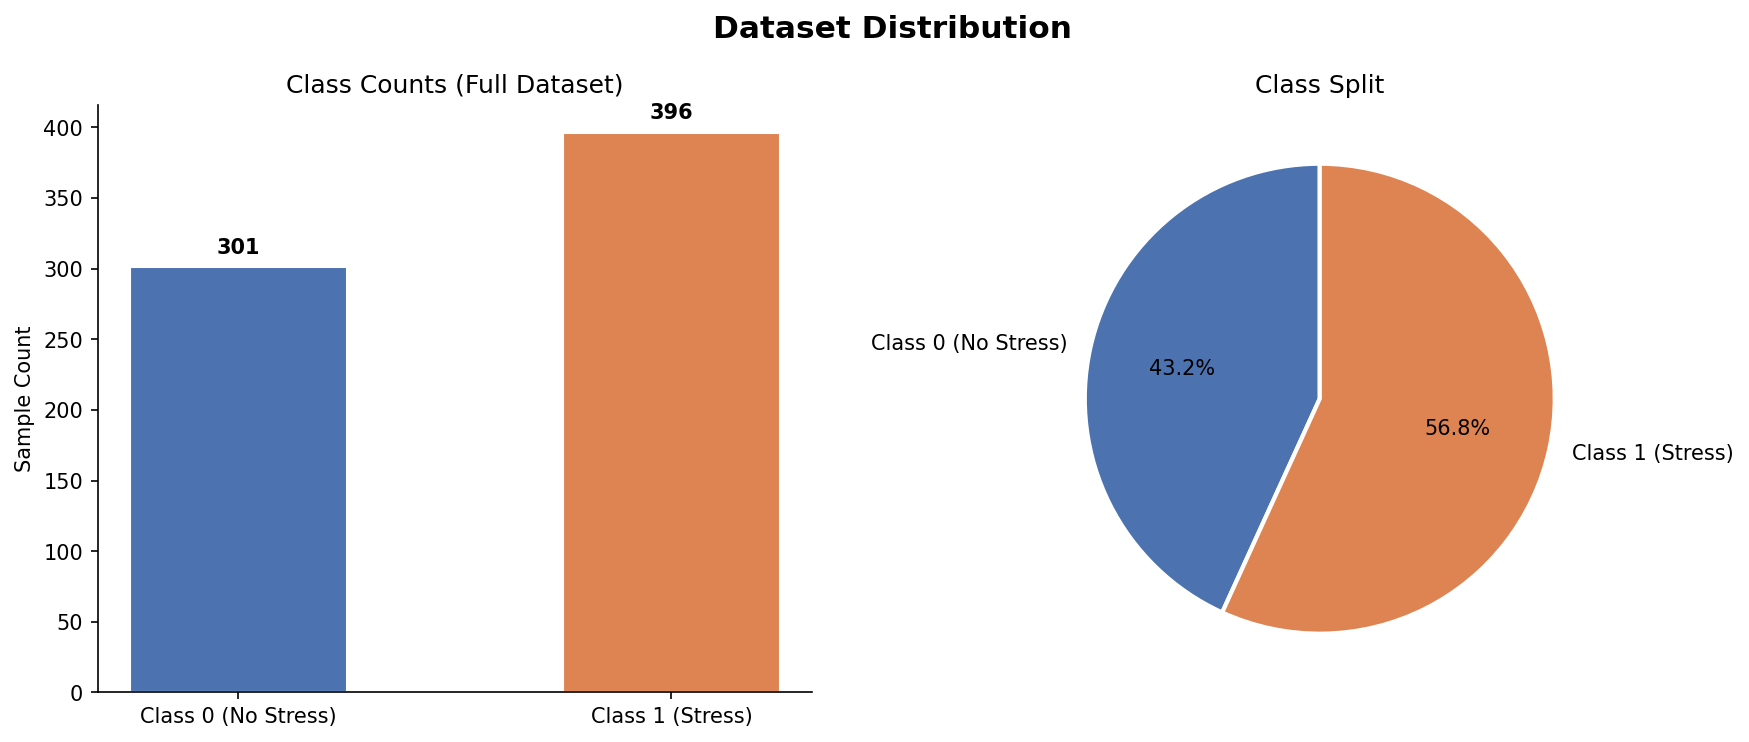

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/01_dataset_distribution.png


In [ ]:
import numpy as np

labels_all  = np.concatenate([y_train, y_val, y_test])
classes     = ["Class 0 (No Stress)", "Class 1 (Stress)"]
counts      = [np.sum(labels_all == 0), np.sum(labels_all == 1)]
colors      = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Dataset Distribution", fontsize=15, fontweight="bold")

# Bar chart
axes[0].bar(classes, counts, color=colors, width=0.5, edgecolor="white")
for i, c in enumerate(counts):
    axes[0].text(i, c + 10, str(c), ha="center", fontweight="bold")
axes[0].set_ylabel("Sample Count")
axes[0].set_title("Class Counts (Full Dataset)")

# Pie chart
axes[1].pie(counts, labels=classes, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Split")

plt.tight_layout()
save("01_dataset_distribution.png")

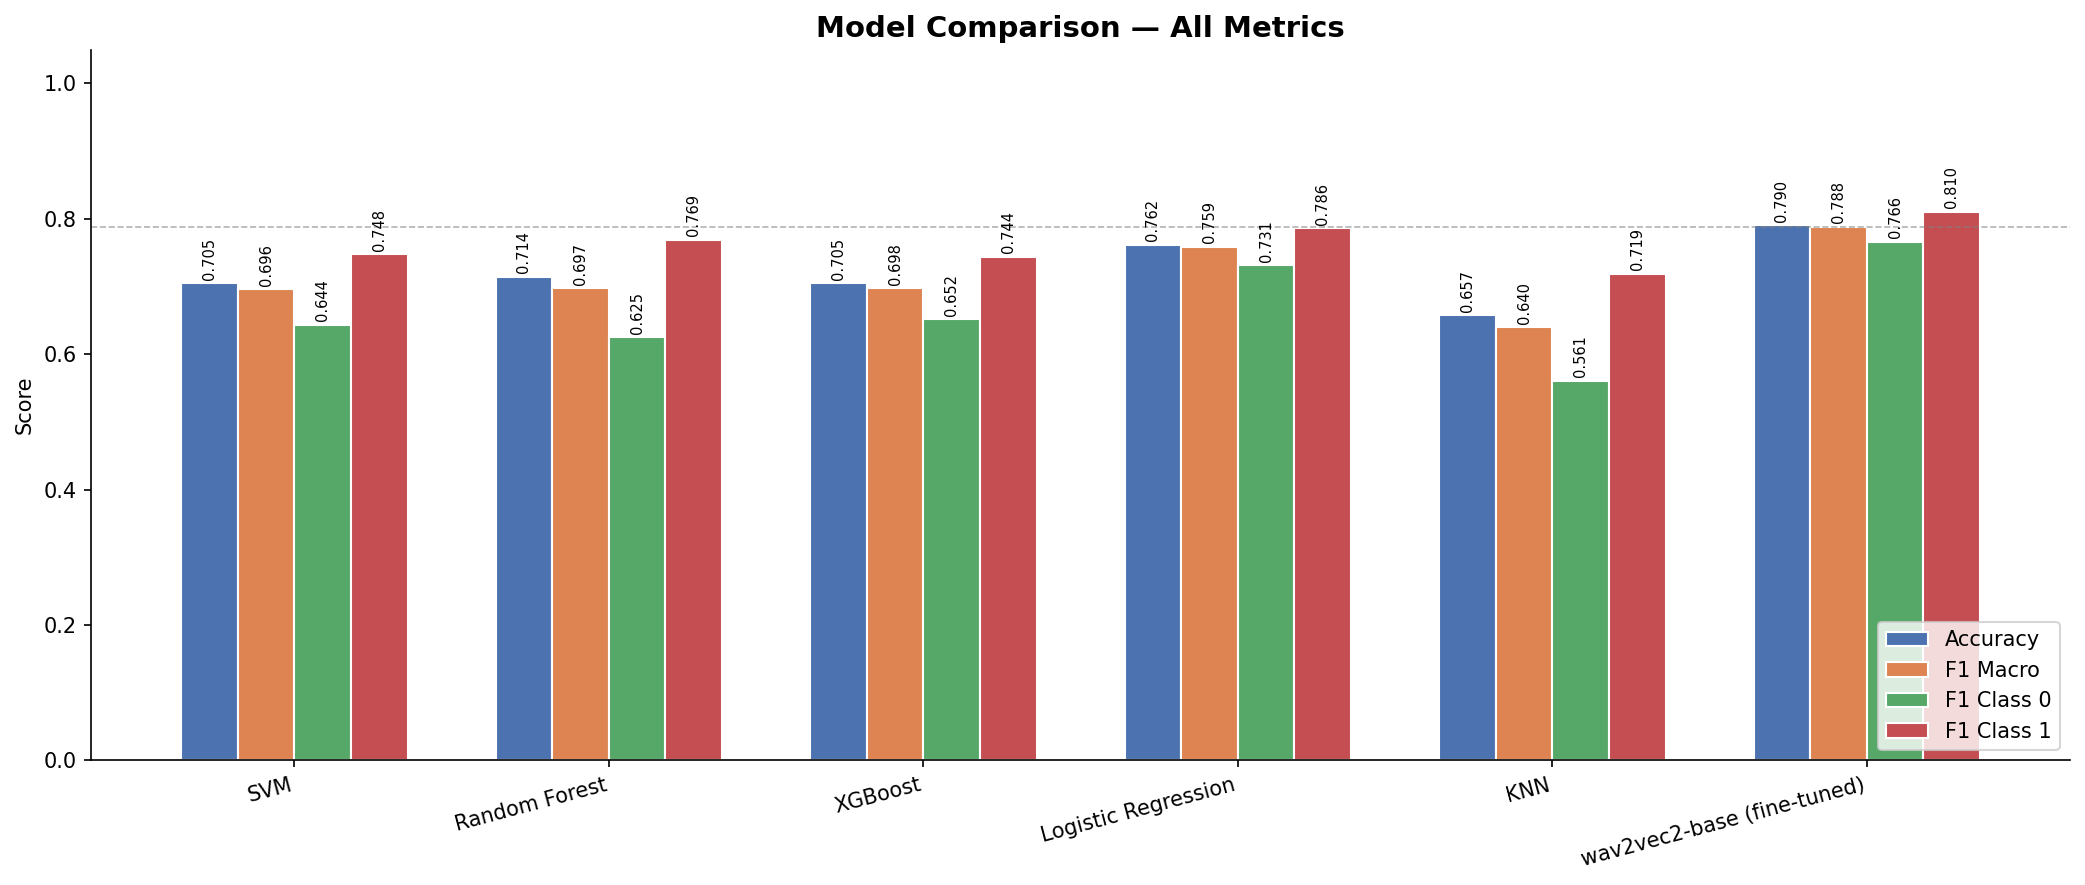

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/02_model_comparison.png


In [ ]:
import pandas as pd

# Your results dict from the ML cell + DL baseline
plot_results = {k: v for k, v in results.items()}   # includes wav2vec2-base (fine-tuned)

df_plot = pd.DataFrame(plot_results).T
metrics = ["Accuracy", "F1 Macro", "F1 Class 0", "F1 Class 1"]
x       = np.arange(len(df_plot))
width   = 0.18
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df_plot[metric], width, label=metric,
                  color=color, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(0.7882, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
           label="DL F1 baseline")

plt.tight_layout()
save("02_model_comparison.png")

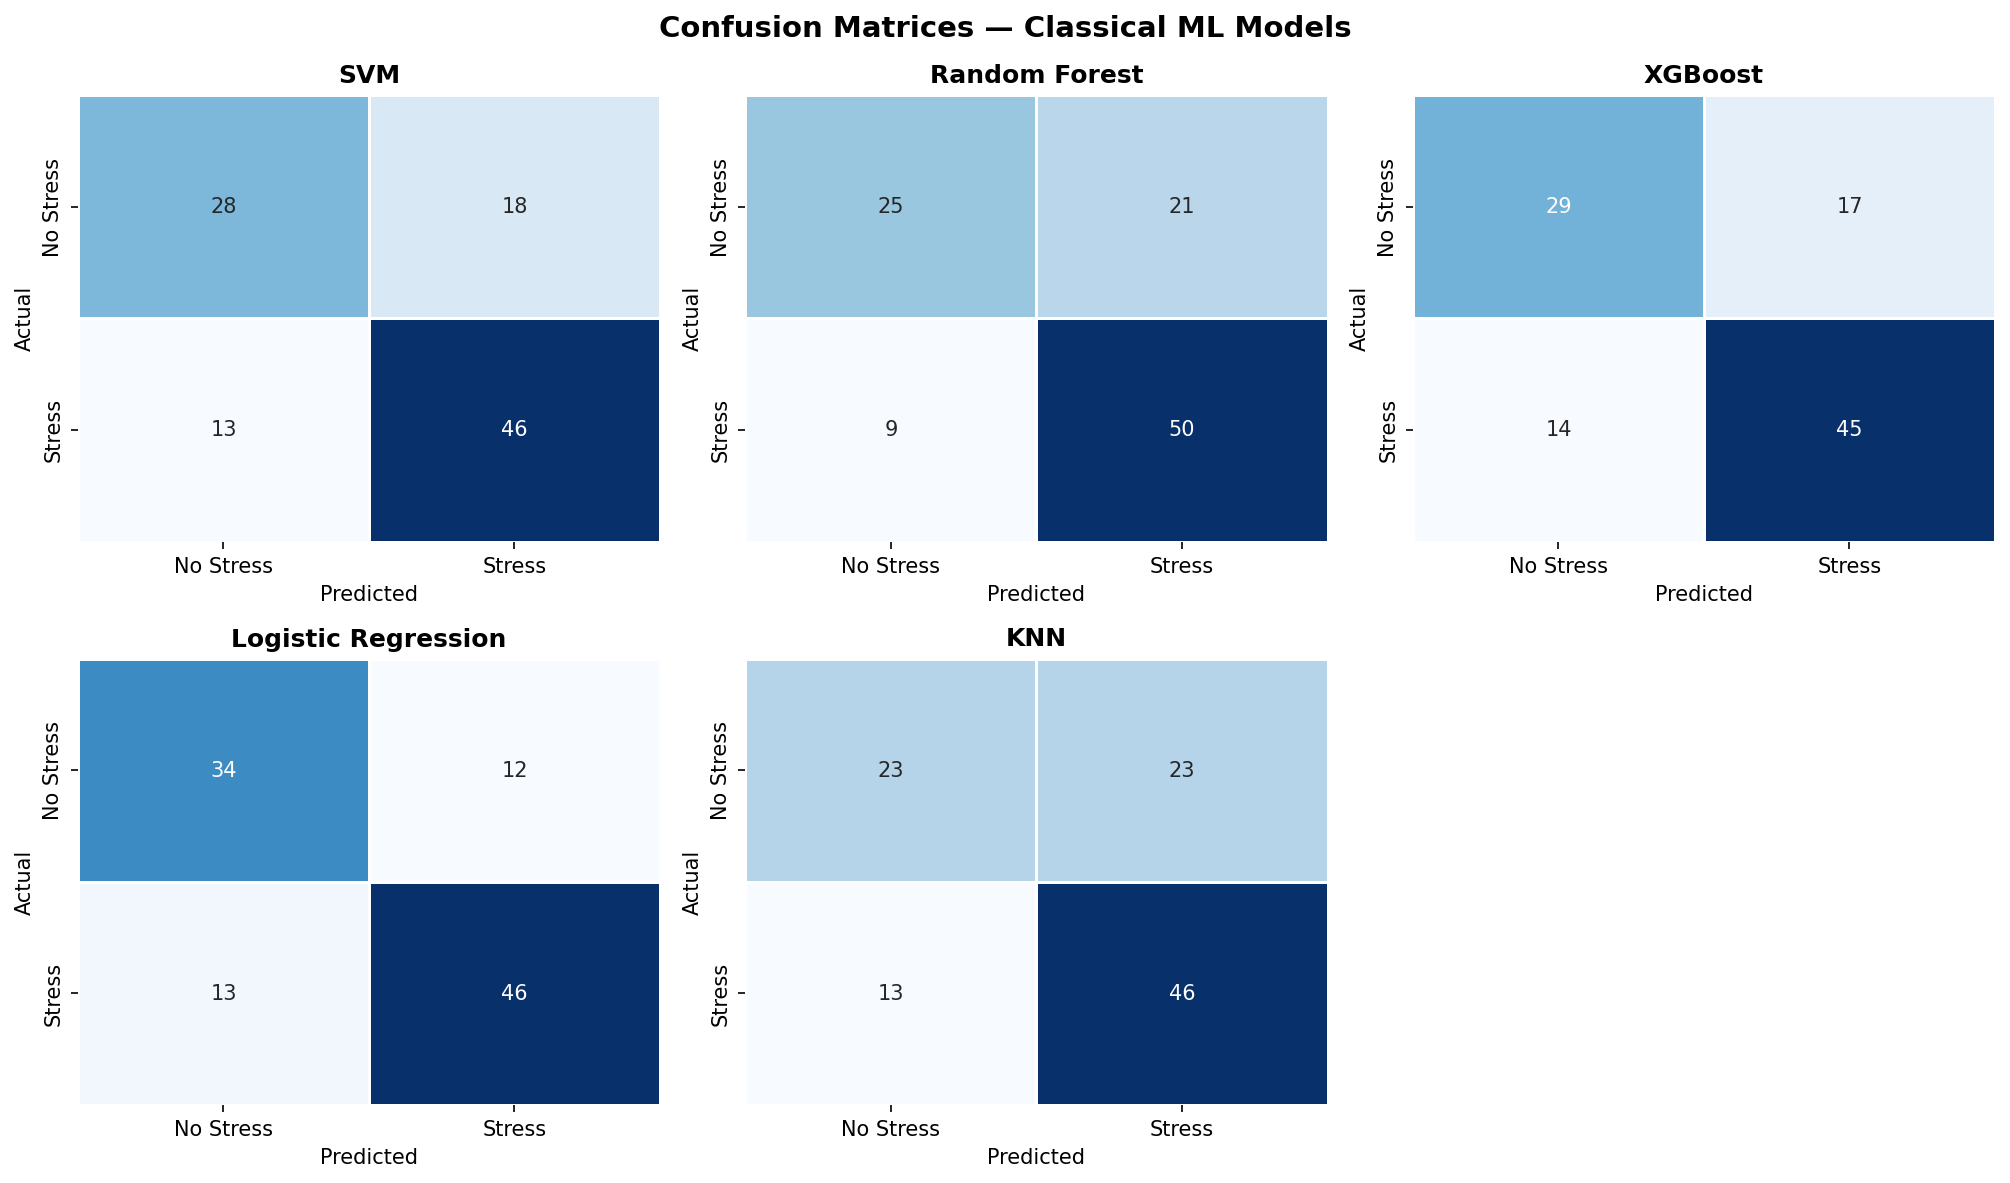

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/03_confusion_matrices.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_models = {**models, "wav2vec2-base (fine-tuned)": None}  # placeholder for DL
# For DL model, load its test preds saved earlier (assumes you have y_pred_dl)
# If you don't have y_pred_dl, skip the DL entry here

n_models = len(models)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes      = axes.flatten()

for idx, (name, clf) in enumerate(models.items()):
    preds = clf.predict(X_test)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["No Stress", "Stress"],
                yticklabels=["No Stress", "Stress"],
                linewidths=0.5, cbar=False)
    axes[idx].set_title(name, fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Confusion Matrices — Classical ML Models", fontsize=14, fontweight="bold")
plt.tight_layout()
save("03_confusion_matrices.png")

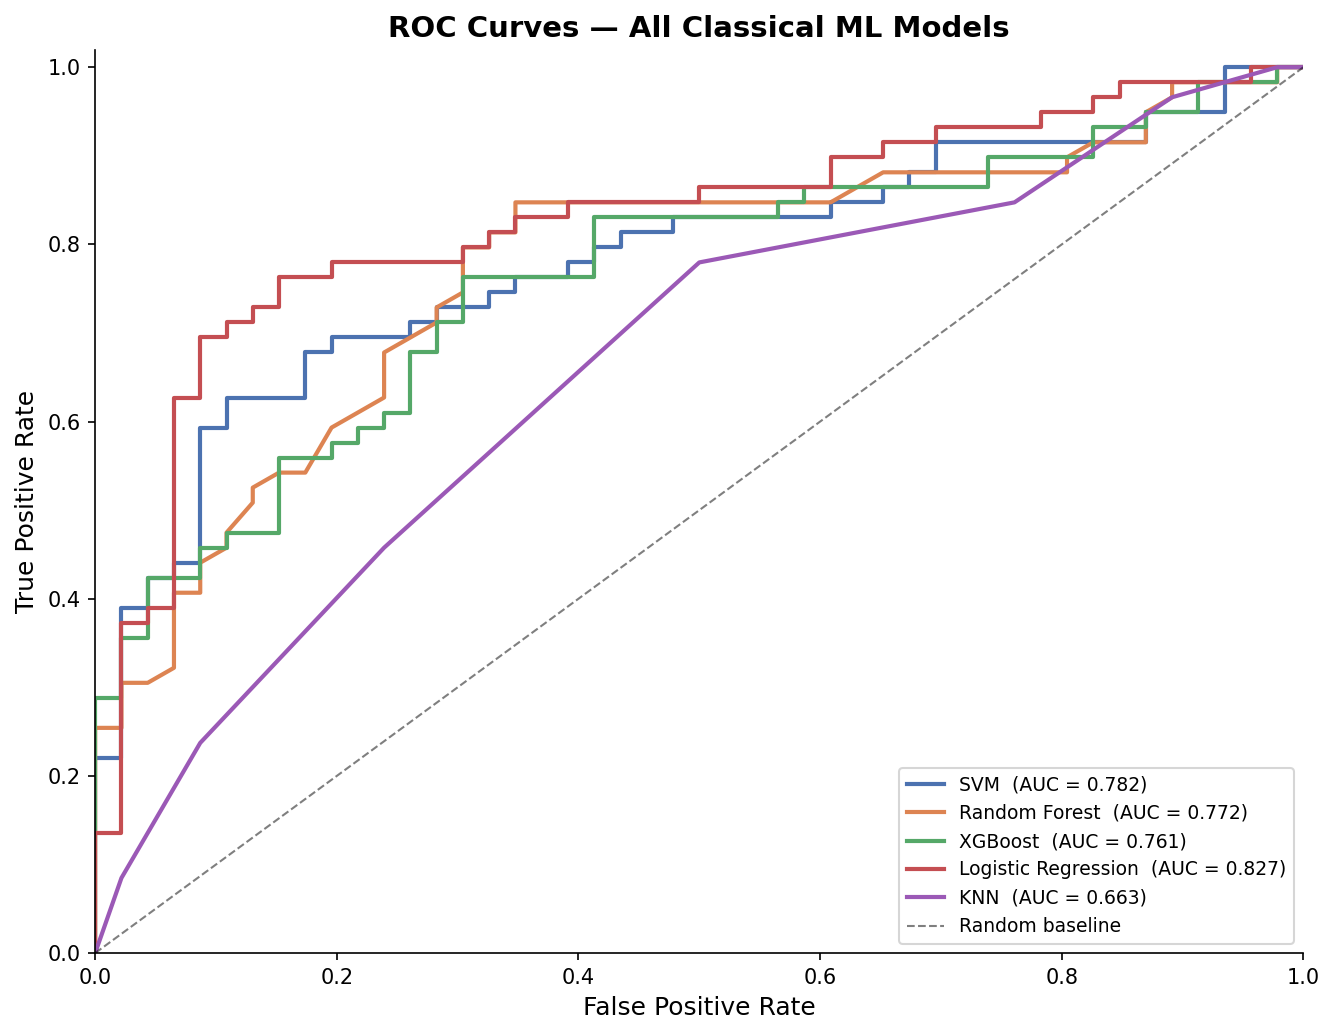

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/04_roc_curves.png


In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9B59B6"]

for (name, clf), color in zip(models.items(), colors_roc):
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_test)[:, 1]
    else:
        proba = clf.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC = {roc_auc:.3f})")

# DL model AUC placeholder — add if you have probabilities from trainer.predict()
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Classical ML Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
save("04_roc_curves.png")

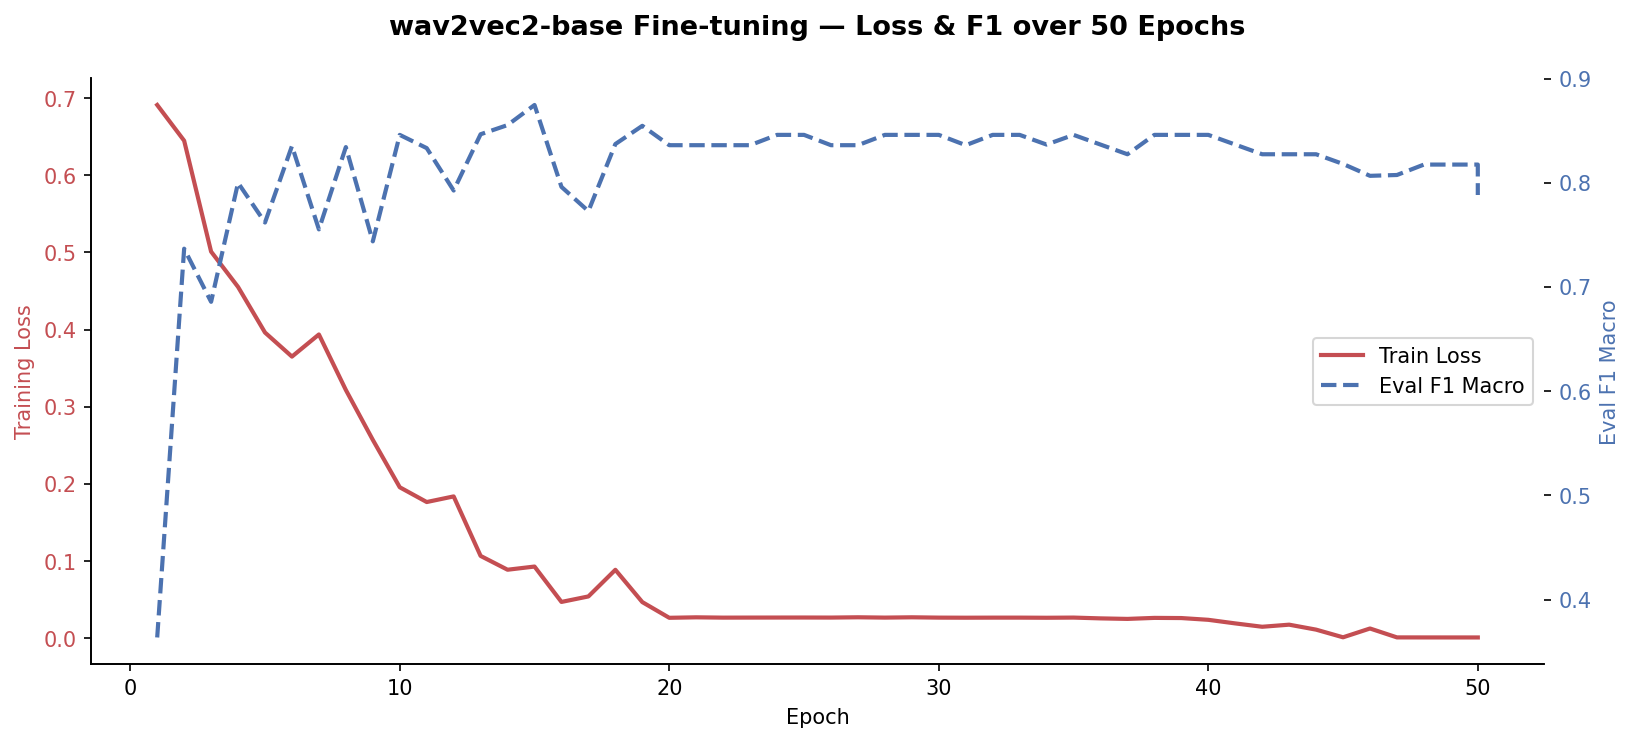

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/05_training_curves.png


In [ ]:
# Pull training history from the Trainer log
log_history = trainer.state.log_history

train_loss, eval_f1, epochs_train, epochs_eval = [], [], [], []

for entry in log_history:
    if "loss" in entry and "epoch" in entry:
        train_loss.append(entry["loss"])
        epochs_train.append(entry["epoch"])
    if "eval_f1_macro" in entry:
        eval_f1.append(entry["eval_f1_macro"])
        epochs_eval.append(entry["epoch"])

fig, ax1 = plt.subplots(figsize=(11, 5))

color_loss = "#C44E52"
color_f1   = "#4C72B0"

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color=color_loss)
ax1.plot(epochs_train, train_loss, color=color_loss, lw=2, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

ax2 = ax1.twinx()
ax2.set_ylabel("Eval F1 Macro", color=color_f1)
ax2.plot(epochs_eval, eval_f1, color=color_f1, lw=2,
         linestyle="--", label="Eval F1 Macro")
ax2.tick_params(axis="y", labelcolor=color_f1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig.suptitle("wav2vec2-base Fine-tuning — Loss & F1 over 50 Epochs",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save("05_training_curves.png")

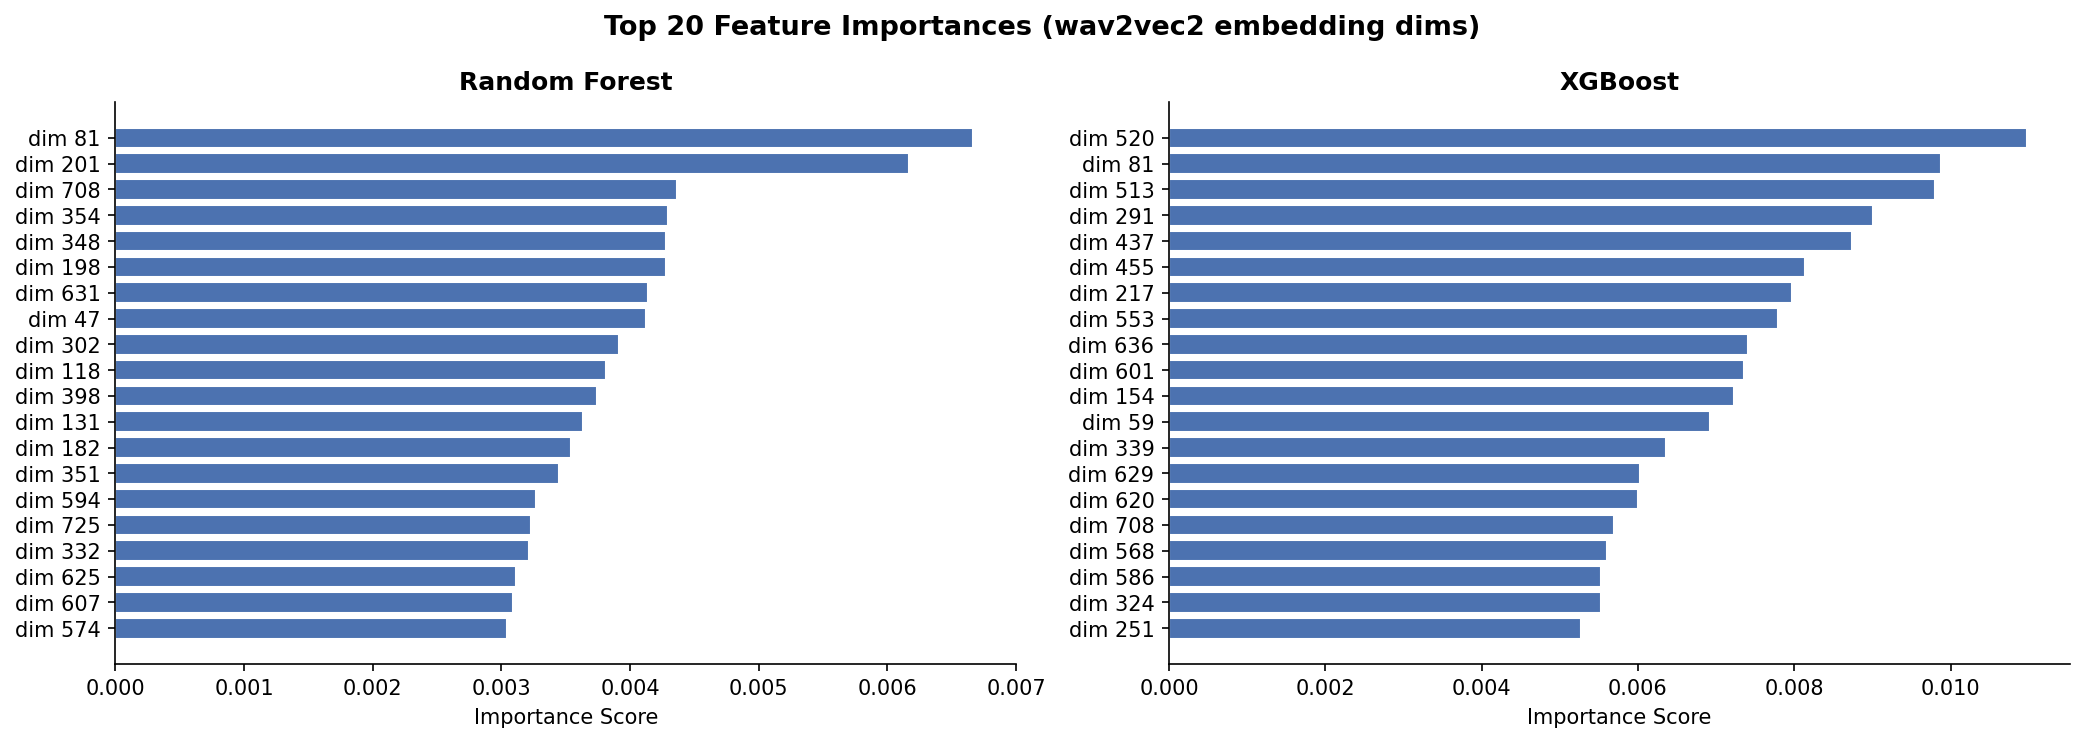

Saved → /content/drive/MyDrive/miniprojectfinal/visuals/06_feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top 20 Feature Importances (wav2vec2 embedding dims)",
             fontsize=13, fontweight="bold")

for ax, (name, key) in zip(axes, [("Random Forest", "Random Forest"),
                                   ("XGBoost",        "XGBoost")]):
    clf         = models[key]
    importances = clf.feature_importances_
    top20_idx   = np.argsort(importances)[-20:][::-1]
    top20_vals  = importances[top20_idx]

    bars = ax.barh([f"dim {i}" for i in top20_idx], top20_vals,
                   color="#4C72B0", edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Importance Score")
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
save("06_feature_importance.png")